
Required preprocessingmm:

*   Select only the required columns:

    * Baseline model features: occupancy_type, loan_amount, state_code, county_code, income, applicant_credit_scoring_model, debt_to_income_ratio, interest_only_payment, property_value, loan_term

    * Sensitive attributes (for fairness analysis): applicant_sex, applicant_race_1, applicant_age

    * Target variable: action_taken

*   Replace missing value markers ("?") with NaN.
*   Trim whitespace from all columns to ensure consistent formatting.

*   Convert numeric columns to numeric type (loan_amount, county_code, income, property_value, loan_term, applicant_sex, applicant_race_1, action_taken). Invalid values are coerced to NaN.

*   Drop rows with missing values in any required column.

*   Filter valid age groups, keeping only:

    <25, 25-34, 35-44, 45-54, 55-64, 65-74, >74

*   Filter the target variable, keeping only loan decisions where:

action_taken ∈ {1,3}

*   Convert the target variable to binary:

    1 → 1 (approved)

    3 → 0 (denied)

*   Filter valid sensitive attribute values:

applicant_sex ∈ {1,2} (male/female)

applicant_race_1 ∈ {2,3,5} (Asian, Black, White)

In [1]:
from statsmodels.stats.proportion import proportion_confint
#
# Helper funcitons
#

race_names = {2: 'Asian', 3: 'Black', 5: 'White'}
# out of the people who truly should be positive,
# how many did the model correctly predict as positive?
def group_tpr(df, group_col):
    for group_value in sorted(df[group_col].dropna().unique()):
        group_df = df[df[group_col] == group_value]
        actual_positive = group_df[group_df['y_true'] == 1.0]

        if len(actual_positive) == 0:
            print(f'{group_col}={group_value}: no actual positives')
            continue

        tpr = (actual_positive['y_pred'] == 1.0).mean()
        print(f'{race_names.get(group_value, group_value)}: TPR = {tpr:.4f}')

def group_fpr(df, group_col):
  for group_value in sorted(df[group_col].dropna().unique()):
      group_df = df[df[group_col] == group_value]
      actual_negative = group_df[group_df['y_true'] == 0.0]

      if len(actual_negative) == 0:
          print(f'{group_col}={group_value}: no actual negatives')
          continue

      fpr = (actual_negative['y_pred'] == 1.0).mean()
      print(f'{race_names.get(group_value, group_value)}: FPR = {fpr:.4f}')



def tpr_by_group(df, group_col):
    """
    For each group value:
    TPR = P(y_pred = 1 | y_true = 1)
    """
    rows = []

    for group_value, g in df.groupby(group_col):
        positives = g[g["y_true"] == 1]

        if len(positives) == 0:
            continue

        tp = (positives["y_pred"] == 1).sum()
        n_positives = len(positives)

        tpr = (positives["y_pred"] == 1).mean()

        low, high = proportion_confint(count=tp, nobs=n_positives, alpha=0.05, method="wilson")

        rows.append({
            group_col: group_value,
            "n_rows": len(g),
            "n_positives": n_positives,
            "tp": int(tp),
            "tpr": tpr,
            "ci_low": low,
            "ci_high": high
        })

    return pd.DataFrame(rows)


def tpr_gap_value(df, group_col):
    tprs = {}

    for group_value in sorted(df[group_col].dropna().unique()):
        group_df = df[df[group_col] == group_value]
        actual_positive = group_df[group_df['y_true'] == 1.0]

        if len(actual_positive) == 0:
            continue

        tpr = (actual_positive['y_pred'] == 1.0).mean()
        tprs[group_value] = tpr

    if len(tprs) < 2:
        return np.nan

    gap = max(tprs.values()) - min(tprs.values())
    return gap



In [2]:
import os
import gc
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive
import numpy as np
import torch
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Mount Google Drive
drive.mount('/content/drive')

# -------- CONFIG --------
# DATA_PATH = "/content/drive/MyDrive/MorganStanley.txt" #change this
DATA_PATH = "/content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv"

report_dir = '/content/drive/MyDrive/EECS6320/Mahin - Adversarial Debiasing/Images'
os.makedirs(report_dir, exist_ok=True)

SEP = "|"
CHUNKSIZE = 50000
TARGET_COL = "action_taken"

# Baseline feature columns
BASELINE_COLS = [
    "occupancy_type",
    "loan_amount",
    "state_code",
    "county_code",
    "income",
    "applicant_credit_scoring_model",
    "debt_to_income_ratio",
    "interest_only_payment",
    "property_value",
    "loan_term",
]

# Sensitive columns for fairness analysis
SENSITIVE_COLS = [
    "applicant_sex",
    "applicant_race_1",
    "applicant_age",
]

COLS = BASELINE_COLS + SENSITIVE_COLS + [TARGET_COL]

OUT_DIR = "/content/processed_baseline" #change this
os.makedirs(OUT_DIR, exist_ok=True)

clean_out = os.path.join(OUT_DIR, "cleaned_baseline.csv")
train_out = os.path.join(OUT_DIR, "train_baseline.csv")
test_out = os.path.join(OUT_DIR, "test_baseline.csv")

# Remove old outputs
for p in [clean_out, train_out, test_out]:
    if os.path.exists(p):
        os.remove(p)

# -------- READ BY COLUMN NAMES, NOT POSITIONS --------
reader = pd.read_csv(
    DATA_PATH,
    sep=SEP,
    usecols=COLS,
    dtype="string",
    chunksize=CHUNKSIZE
)

clean_rows = 0

# -------- CLEAN DATA --------
for chunk in reader:
    chunk = chunk.replace("?", pd.NA)

    if len(chunk) == 0:
        continue

    # Strip whitespace
    for c in COLS:
        chunk[c] = chunk[c].astype("string").str.strip()

    # Convert numeric columns
    numeric_cols = [
        "loan_amount",
        "county_code",
        "income",
        "property_value",
        "loan_term",
        "applicant_sex",
        "applicant_race_1",
        TARGET_COL,
    ]

    for c in numeric_cols:
        chunk[c] = pd.to_numeric(chunk[c], errors="coerce")

    # Keep age as string unless you confirm it is numeric
    chunk["applicant_age"] = chunk["applicant_age"].astype("string").str.strip()

    # Drop rows missing required columns
    chunk = chunk.dropna(subset=COLS)
    if len(chunk) == 0:
        continue


    # Debug check
    # print(chunk[["loan_amount", "property_value", "applicant_age", TARGET_COL]].head())

    # filter for applicant_age
    VALID_AGES = ["<25","25-34","35-44","45-54","55-64","65-74",">74"]

    chunk = chunk[chunk["applicant_age"].isin(VALID_AGES)]

    if len(chunk) == 0:
       continue
    # Keep only action_taken in {1,3}
    chunk = chunk[chunk[TARGET_COL].isin([1, 3])].copy()
    if len(chunk) == 0:
        continue

    # Optional fairness filters
    chunk = chunk[
        chunk["applicant_sex"].isin([1, 2]) &
        chunk["applicant_race_1"].isin([2, 3, 5])
    ].copy()
    if len(chunk) == 0:
        continue

    # Convert target: 1 = approved -> 1, 3 = denied -> 0
    chunk[TARGET_COL] = chunk[TARGET_COL].map({1: 1, 3: 0}).astype(int)

    # Append cleaned chunk
    chunk.to_csv(
        clean_out,
        mode="a",
        header=(clean_rows == 0),
        index=False
    )

    clean_rows += len(chunk)

    del chunk
    gc.collect()

print("Cleaning done.")
print("Saved cleaned file:", clean_out, "rows:", clean_rows)

if clean_rows == 0:
    raise ValueError("No rows survived preprocessing. Check the raw column values.")

# -------- LOAD CLEANED DATA --------
df = pd.read_csv(clean_out)

# print("---------------------------------")
# print("Cleaned dataset shape:", df.shape)
# print("Cleaned dataset columns:",df.columns)
# print("Cleaned dataset lei:",df["lei"].head())
# print("Cleaned dataset unique:",df["lei"].nunique())
# print("---------------------------------")

# -------- TRAIN / TEST SPLIT --------
df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    train_size=0.80,
    random_state=seed,
    stratify=df[TARGET_COL] if df[TARGET_COL].nunique() > 1 else None
)

# Save raw train/test with sensitive columns preserved
df_train.to_csv(train_out, index=False)
df_test.to_csv(test_out, index=False)

Mounted at /content/drive
Cleaning done.
Saved cleaned file: /content/processed_baseline/cleaned_baseline.csv rows: 83503


Train + predict + evaluate (Random Forest)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths
TRAIN_CSV = "/content/processed_baseline/train_baseline.csv"
TEST_CSV  = "/content/processed_baseline/test_baseline.csv"

# Baseline feature columns
FEATURE_COLS = [
    "occupancy_type",
    "loan_amount",
    "state_code",
    "county_code",
    "income",
    "applicant_credit_scoring_model",
    "debt_to_income_ratio",
    "interest_only_payment",
    "property_value",
    "loan_term",
    "applicant_race_1"
]

TARGET_COL = "action_taken"

numeric_cols = [
    'loan_amount',
    'county_code',
    'income',
    'property_value',
    'loan_term',
    "applicant_race_1"
]

categorical_cols = [
    'occupancy_type',
    'state_code',
    'applicant_credit_scoring_model',
    'debt_to_income_ratio',
    'interest_only_payment'
]

# Load datasets
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

X_train = df_train[numeric_cols + categorical_cols]
X_test = df_test[numeric_cols + categorical_cols]

y_train = df_train['action_taken']
y_test = df_test['action_taken']

fairness_cols = [
    'applicant_sex',
    'applicant_race_1',
    'applicant_age'
]

fairness_train = df_train[fairness_cols]
fairness_test = df_test[fairness_cols]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from torch.utils.data import TensorDataset, DataLoader

imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
scaler = StandardScaler()

numeric_pipeline = Pipeline([
    ('imputer', imp_median),
    ('scaler', scaler)
])

imp_categorical = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore')

categorical_pipeline = Pipeline([
    ('imputer', imp_categorical),
    ('encoder', encoder)
])

col_transformer = ColumnTransformer([
    ('numerical', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

col_transformer.fit(X_train)

X_train_processed = col_transformer.transform(X_train)
X_test_processed = col_transformer.transform(X_test)

y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

X_train_dense = np.array(X_train_processed.todense())
X_test_dense = np.array(X_test_processed.todense())

In [5]:
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_dense, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_array, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_array, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

epochs = 150

# 96 number of features
input_dim = X_train_tensor.shape[1]

#
# baseline Model
#
class BaselineMLP(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(input_dim, 64)
    self.relu = nn.ReLU()
    self.output_layer = nn.Linear(64, 1)

  def forward(self, x):
    h = self.hidden_layer(x)
    h = self.relu(h)
    out = self.output_layer(h)
    return out, h


model_baseline = BaselineMLP(input_dim)

#
# Baseline training
#

criterion_baseline = nn.BCEWithLogitsLoss()
optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=0.001)

for epoch in range(epochs):

    for X_batch, y_batch in train_loader:
        y_batch = y_batch.view(-1, 1)

        optimizer_baseline.zero_grad()

        logits, hidden_representation = model_baseline(X_batch)

        loss = criterion_baseline(logits, y_batch)

        loss.backward()
        optimizer_baseline.step()



model_baseline.eval()

all_logits_baseline = []
all_preds_baseline = []
all_y_baseline = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits, hidden_representation = model_baseline(X_batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_logits_baseline.append(logits)
        all_preds_baseline.append(preds)
        all_y_baseline.append(y_batch.view(-1, 1))

y_pred_tensor_baseline = torch.cat(all_preds_baseline, dim=0)
y_test_tensor_eval_baseline = torch.cat(all_y_baseline, dim=0)

accuracy_baseline = (y_pred_tensor_baseline == y_test_tensor_eval_baseline).float().mean()

# convert PyTorch tensors into NumPy arrays
y_true_baseline = y_test_tensor_eval_baseline.cpu().numpy().ravel()
y_pred_baseline = y_pred_tensor_baseline.cpu().numpy().ravel()

# copy of fairness test dataframe
fairness_test_eval_baseline = fairness_test.reset_index(drop=True).copy()

# adding info to dataframe
# group information like sex, race, age
# true class
# predicted class
fairness_test_eval_baseline['y_true'] = y_true_baseline
fairness_test_eval_baseline['y_pred'] = y_pred_baseline


In [6]:
# for adversary training
numeric_cols_debias = [
    'loan_amount',
    'county_code',
    'income',
    'property_value',
    'loan_term'
]

categorical_cols_debias = [
    'occupancy_type',
    'state_code',
    'applicant_credit_scoring_model',
    'debt_to_income_ratio',
    'interest_only_payment'
]

X_train_debias = df_train[numeric_cols_debias + categorical_cols_debias]
X_test_debias = df_test[numeric_cols_debias + categorical_cols_debias]

col_transformer_debias = ColumnTransformer([
    ('numerical', numeric_pipeline, numeric_cols_debias),
    ('categorical', categorical_pipeline, categorical_cols_debias)
])

col_transformer_debias.fit(X_train_debias)
X_train_processed_debias = col_transformer_debias.transform(X_train_debias)
X_test_processed_debias = col_transformer_debias.transform(X_test_debias)

X_train_dense_debias = np.array(X_train_processed_debias.todense())
X_test_dense_debias = np.array(X_test_processed_debias.todense())

X_train_tensor_debias = torch.tensor(X_train_dense_debias, dtype=torch.float32)
X_test_tensor_debias = torch.tensor(X_test_dense_debias, dtype=torch.float32)


adversary_target_lbls = fairness_train['applicant_race_1'].copy()

adversary_target_lbls = adversary_target_lbls.map({2: 0, 3: 1, 5: 2})
adv_tgt_lbls_tensor = torch.tensor(adversary_target_lbls)

class_counts = torch.bincount(adv_tgt_lbls_tensor).float()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)


train_dataset_adv = TensorDataset(X_train_tensor_debias, y_train_tensor, adv_tgt_lbls_tensor)
train_loader_adv = DataLoader(train_dataset_adv, batch_size=256, shuffle=True)

test_dataset_debias = TensorDataset(X_test_tensor_debias, y_test_tensor)
test_loader_debias = DataLoader(test_dataset_debias, batch_size=256, shuffle=False)
# Debiasing

class ModelToBeFixedMLP(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(input_dim, 64)
    self.relu = nn.ReLU()
    self.output_layer = nn.Linear(64, 1)

  def forward(self, x):
    h = self.hidden_layer(x)
    h = self.relu(h)
    out = self.output_layer(h)
    return out, h

input_dim_debias = X_train_tensor_debias.shape[1]
modelToBeFixed = ModelToBeFixedMLP(input_dim_debias)



# adversary model
hidden_dim = 64
class AdversaryModel(nn.Module):
  def __init__(self, hidden_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(hidden_dim, 32)
    self.relu = nn.ReLU()
    self.output_layer = nn.Linear(32, 3)

  def forward(self, x):
    h = self.hidden_layer(x)
    h = self.relu(h)
    out = self.output_layer(h)
    return out


adversary_model = AdversaryModel(hidden_dim)



#
# Model to be fixed training
#

criterion_toBeFixed = nn.BCEWithLogitsLoss()
# multiclass classification loss needs cross entropy loss
criterion_adv = nn.CrossEntropyLoss(weight=class_weights)
# criterion_adv = nn.CrossEntropyLoss()


optimizer_main = torch.optim.Adam(modelToBeFixed.parameters(), lr=0.001)
optimizer_adv = torch.optim.Adam(adversary_model.parameters(), lr=0.001)

lambda_adv = 0.4


modelToBeFixed.train()
adversary_model.train()

for epoch in range(epochs):
    running_main_loss = 0.0
    running_adv_loss = 0.0
    running_total_loss = 0.0

    for X_batch, y_batch, race_batch in train_loader_adv:
        y_batch = y_batch.view(-1, 1)

        # -----------------------------
        # Step 1: train adversary
        # -----------------------------

        optimizer_adv.zero_grad()
        logits, hidden_representation = modelToBeFixed(X_batch)

        race_logits = adversary_model(hidden_representation.detach())
        adv_loss = criterion_adv(race_logits, race_batch)

        adv_loss.backward()
        optimizer_adv.step()

        # -----------------------------
        # Step 2: train predictor
        # -----------------------------
        optimizer_main.zero_grad()

        logits, hidden_representation = modelToBeFixed(X_batch)
        race_logits = adversary_model(hidden_representation)

        main_loss = criterion_toBeFixed(logits, y_batch)
        adv_loss_for_predictor = criterion_adv(race_logits, race_batch)

        total_loss = main_loss - lambda_adv * adv_loss_for_predictor

        total_loss.backward()
        optimizer_main.step()
        running_main_loss += main_loss.item()
        running_adv_loss += adv_loss_for_predictor.item()
        running_total_loss += total_loss.item()

    avg_main_loss = running_main_loss / len(train_loader_adv)
    avg_adv_loss = running_adv_loss / len(train_loader_adv)
    avg_total_loss = running_total_loss / len(train_loader_adv)


modelToBeFixed.eval()

all_logits = []
all_preds = []
all_probs = []
all_y = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_debias:
        logits, hidden_representation = modelToBeFixed(X_batch)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        all_logits.append(logits)
        all_preds.append(preds)
        all_y.append(y_batch.view(-1, 1))
        all_probs.append(probs)

y_pred_tensor = torch.cat(all_preds, dim=0)
y_test_tensor_eval = torch.cat(all_y, dim=0)
y_prob_tensor = torch.cat(all_probs, dim=0)

accuracyToBeFixed = (y_pred_tensor == y_test_tensor_eval).float().mean()


# convert PyTorch tensors into NumPy arrays
y_true = y_test_tensor_eval.cpu().numpy().ravel()
y_pred = y_pred_tensor.cpu().numpy().ravel()
y_prob = y_prob_tensor.cpu().numpy().ravel()

# copy of fairness test dataframe
fairness_test_eval = fairness_test.reset_index(drop=True).copy()

# adding info to dataframe
# group information like sex, race, age
# true class
# predicted class
fairness_test_eval['y_true'] = y_true
fairness_test_eval['y_pred'] = y_pred
fairness_test_eval['y_prob'] = y_prob

fairness_test_eval[['y_true', 'y_pred', 'y_prob']].head()


,y_true,y_pred,y_prob
0,0.0,0.0,9.230565e-02
1,0.0,1.0,5.035993e-01
2,1.0,1.0,5.655814e-01
3,0.0,0.0,2.786390e-07
4,0.0,1.0,8.317913e-01


In [7]:

print('-----------Baseline--------------')
print(f'Test Accuracy: {accuracy_baseline.item():.4f}')
group_tpr(fairness_test_eval_baseline, 'applicant_race_1')
print(f'Biggest TPR GAP {tpr_gap_value(fairness_test_eval_baseline, "applicant_race_1"):.4f}')
group_fpr(fairness_test_eval_baseline, 'applicant_race_1')


print('\n')
print('-----------Debiased--------------')
print(f'Test Accuracy: {accuracyToBeFixed.item():.4f}')
group_tpr(fairness_test_eval, 'applicant_race_1')
print(f'Biggest TPR GAP {tpr_gap_value(fairness_test_eval, "applicant_race_1"):.4f}')
group_fpr(fairness_test_eval, 'applicant_race_1')


-----------Baseline--------------
Test Accuracy: 0.8413
Asian: TPR = 0.8235
Black: TPR = 0.5686
White: TPR = 0.6827
Biggest TPR GAP 0.2549
Asian: FPR = 0.1224
Black: FPR = 0.0733
White: FPR = 0.1027


-----------Debiased--------------
Test Accuracy: 0.8365
Asian: TPR = 0.7059
Black: TPR = 0.6346
White: TPR = 0.6898
Biggest TPR GAP 0.0713
Asian: FPR = 0.1020
Black: FPR = 0.1041
White: FPR = 0.1089


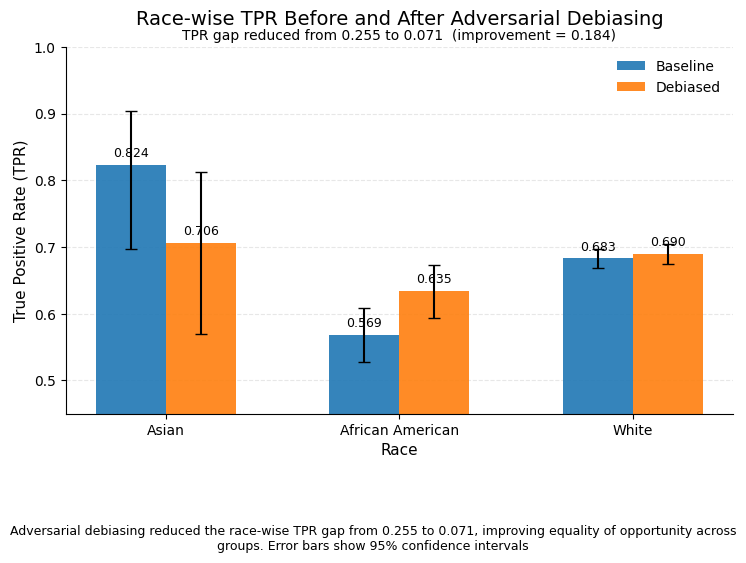

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


race_tpr_df = tpr_by_group(fairness_test_eval_baseline, 'applicant_race_1').copy()
race_tpr_df['race_label'] = race_tpr_df['applicant_race_1'].map({
    2: 'Asian',
    3: 'African American',
    5: 'White'
})

race_tpr_df['err_low'] = race_tpr_df['tpr'] - race_tpr_df['ci_low']
race_tpr_df['err_high'] = race_tpr_df['ci_high'] - race_tpr_df['tpr']


race_order = ['Asian', 'African American', 'White']
race_tpr_df['race_label'] = pd.Categorical(
    race_tpr_df['race_label'],
    categories=race_order,
    ordered=True
)
race_tpr_df = race_tpr_df.sort_values('race_label').reset_index(drop=True)
yerr = [race_tpr_df["err_low"], race_tpr_df["err_high"]]
yerr_baseline = [race_tpr_df["err_low"].values, race_tpr_df["err_high"].values]



df_debiased = tpr_by_group(fairness_test_eval, 'applicant_race_1').copy()
df_debiased['race_label'] = df_debiased['applicant_race_1'].map({
    2: 'Asian',
    3: 'African American',
    5: 'White'
})
df_debiased['race_label'] = pd.Categorical(
    df_debiased['race_label'],
    categories=race_order,
    ordered=True
)
df_debiased = df_debiased.sort_values('race_label').reset_index(drop=True)

df_debiased['err_low'] = df_debiased['tpr'] - df_debiased['ci_low']
df_debiased['err_high'] = df_debiased['ci_high'] - df_debiased['tpr']
yerr_debiased = [df_debiased["err_low"].values, df_debiased["err_high"].values]

plot_df = race_tpr_df[['race_label', 'tpr']].copy()
plot_df = plot_df.rename(columns={'tpr': 'Baseline'})
plot_df['Debiased'] = df_debiased['tpr'].values

baseline_gap = plot_df['Baseline'].max() - plot_df['Baseline'].min()
debiased_gap = plot_df['Debiased'].max() - plot_df['Debiased'].min()
gap_improvement = baseline_gap - debiased_gap

x = np.arange(len(plot_df))
bar_width = 0.30

fig, ax = plt.subplots(figsize=(7.5, 5.2))

bars1 = ax.bar(
    x - bar_width/2,
    plot_df['Baseline'],
    width=bar_width,
    label='Baseline',
    alpha=0.9,
    yerr=yerr_baseline,
    capsize=4
)

bars2 = ax.bar(
    x + bar_width/2,
    plot_df['Debiased'],
    width=bar_width,
    label='Debiased',
    yerr=yerr_debiased,
    capsize=4,
    alpha=0.9
)



ax.set_title('Race-wise TPR Before and After Adversarial Debiasing', fontsize=14, pad=16)
ax.text(
    0.5, 1.02,
    f'TPR gap reduced from {baseline_gap:.3f} to {debiased_gap:.3f}  (improvement = {gap_improvement:.3f})',
    transform=ax.transAxes,
    ha='center',
    fontsize=10
)

ax.set_xlabel('Race', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['race_label'], fontsize=10)
ax.set_ylim(0.45, 1.00)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10)

for bar, err_high in zip(bars1, race_tpr_df["err_high"].values):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + err_high + 0.008,
        f'{h:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
        clip_on=False
    )

for bar, err_high in zip(bars2, df_debiased["err_high"].values):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + err_high + 0.008,
        f'{h:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
        clip_on=False
    )

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(
    0.5, -0.02,
    f"Adversarial debiasing reduced the race-wise TPR gap from {baseline_gap:.3f} to {debiased_gap:.3f}, improving equality of opportunity across groups. Error bars show 95% confidence intervals",
    ha='center',
    va='top',
    fontsize=9,
    wrap=True
)
plt.savefig("tpr_by_race.png", dpi=300, bbox_inches="tight")

plt.savefig(os.path.join(report_dir, 'racewiseTPR.png'), dpi=300, bbox_inches='tight')

plt.show()


========== CALIBRATION (Baseline ECE) ==========
 applicant_race_1      group_label      ECE   ci_low  ci_high  err_low  err_high
                2            Asian 0.063362 0.047754 0.125324 0.015608  0.061962
                3 African American 0.027122 0.020092 0.038000 0.007030  0.010877
                5            White 0.025845 0.021139 0.031711 0.004706  0.005866

========== CALIBRATION (Debiased ECE) ==========
 applicant_race_1      group_label      ECE   ci_low  ci_high  err_low  err_high
                2            Asian 0.089252 0.071408 0.150060 0.017844  0.060809
                3 African American 0.039252 0.032522 0.050523 0.006729  0.011272
                5            White 0.025557 0.021197 0.032033 0.004360  0.006476


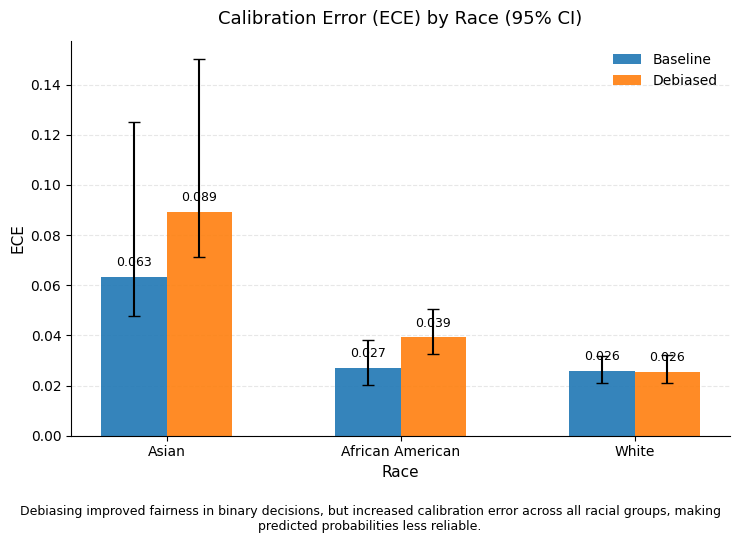

In [ ]:
baseline_probs = torch.sigmoid(torch.cat(all_logits_baseline, dim=0)).cpu().numpy().ravel()
debiased_probs = torch.sigmoid(torch.cat(all_logits, dim=0)).cpu().numpy().ravel()

fairness_test_eval_baseline = fairness_test_eval_baseline.copy()
fairness_test_eval = fairness_test_eval.copy()

fairness_test_eval_baseline["y_score"] = baseline_probs
fairness_test_eval["y_score"] = debiased_probs

race_names = {2: "Asian", 3: "African American", 5: "White"}
race_order = [2, 3, 5]


# =========================================================
# 3) Calibration helper functions
# =========================================================
def calibration_table_by_group(df, group_col, n_bins=10):
    rows = []
    bin_edges = np.linspace(0, 1, n_bins + 1)

    for group_value in sorted(df[group_col].dropna().unique()):
        g = df[df[group_col] == group_value].copy()

        y_true = g["y_true"].values
        y_score = g["y_score"].values

        bin_ids = np.digitize(y_score, bin_edges[1:-1], right=True)

        for b in range(n_bins):
            mask = (bin_ids == b)
            if mask.sum() == 0:
                continue

            avg_score = y_score[mask].mean()
            empirical_rate = y_true[mask].mean()
            abs_error = abs(empirical_rate - avg_score)

            rows.append({
                group_col: group_value,
                "group_label": race_names.get(group_value, str(group_value)),
                "bin_id": b,
                "bin_left": bin_edges[b],
                "bin_right": bin_edges[b + 1],
                "count": int(mask.sum()),
                "avg_score": avg_score,
                "empirical_rate": empirical_rate,
                "abs_error": abs_error
            })

    return pd.DataFrame(rows)


def ece_by_group(df, group_col, n_bins=10):
    cal_df = calibration_table_by_group(df, group_col, n_bins=n_bins)

    rows = []
    for group_value in sorted(cal_df[group_col].dropna().unique()):
        g = cal_df[cal_df[group_col] == group_value].copy()
        total = g["count"].sum()

        ece = ((g["count"] / total) * g["abs_error"]).sum()

        rows.append({
            group_col: group_value,
            "group_label": race_names.get(group_value, str(group_value)),
            "ECE": ece
        })

    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)


def bootstrap_ece_ci_by_group(df, group_col, n_bins=10, n_boot=1000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []

    for group_value in sorted(df[group_col].dropna().unique()):
        g = df[df[group_col] == group_value].copy().reset_index(drop=True)

        # Point estimate on the original group data
        ece_df = ece_by_group(g, group_col, n_bins=n_bins)
        point_ece = ece_df["ECE"].iloc[0]

        # Bootstrap ECE values
        boot_eces = []
        for _ in range(n_boot):
            sample_idx = rng.integers(0, len(g), size=len(g))
            g_boot = g.iloc[sample_idx].copy().reset_index(drop=True)

            boot_ece_df = ece_by_group(g_boot, group_col, n_bins=n_bins)
            boot_eces.append(boot_ece_df["ECE"].iloc[0])

        ci_low = np.percentile(boot_eces, 100 * (alpha / 2))
        ci_high = np.percentile(boot_eces, 100 * (1 - alpha / 2))

        rows.append({
            group_col: group_value,
            "group_label": race_names.get(group_value, str(group_value)),
            "ECE": point_ece,
            "ci_low": ci_low,
            "ci_high": ci_high
        })

    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)


# =========================================================
# 5) Compute calibration metrics
# =========================================================
baseline_cal_bins = calibration_table_by_group(fairness_test_eval_baseline, "applicant_race_1", n_bins=10)
debiased_cal_bins = calibration_table_by_group(fairness_test_eval, "applicant_race_1", n_bins=10)

# baseline_ece = ece_by_group(fairness_test_eval_baseline, "applicant_race_1", n_bins=10)
# debiased_ece = ece_by_group(fairness_test_eval, "applicant_race_1", n_bins=10)

baseline_ece = bootstrap_ece_ci_by_group(fairness_test_eval_baseline, "applicant_race_1", n_bins=10)
debiased_ece = bootstrap_ece_ci_by_group(fairness_test_eval, "applicant_race_1", n_bins=10)
baseline_ece["err_low"] = baseline_ece["ECE"] - baseline_ece["ci_low"]
baseline_ece["err_high"] = baseline_ece["ci_high"] - baseline_ece["ECE"]

debiased_ece["err_low"] = debiased_ece["ECE"] - debiased_ece["ci_low"]
debiased_ece["err_high"] = debiased_ece["ci_high"] - debiased_ece["ECE"]
print("\n========== CALIBRATION (Baseline ECE) ==========")
print(baseline_ece.to_string(index=False))

print("\n========== CALIBRATION (Debiased ECE) ==========")
print(debiased_ece.to_string(index=False))



# =========================================================
# 8) ECE bar chart
# =========================================================
ece_plot = baseline_ece.copy()
ece_plot = ece_plot.rename(columns={"ECE": "Baseline_ECE"})
ece_plot["Baseline_err_low"] = baseline_ece["err_low"].values
ece_plot["Baseline_err_high"] = baseline_ece["err_high"].values

ece_plot["Debiased_ECE"] = debiased_ece["ECE"].values
ece_plot["Debiased_err_low"] = debiased_ece["err_low"].values
ece_plot["Debiased_err_high"] = debiased_ece["err_high"].values

ece_plot["group_label"] = pd.Categorical(
    ece_plot["group_label"],
    categories=[race_names[r] for r in race_order],
    ordered=True
)
ece_plot = ece_plot.sort_values("group_label").reset_index(drop=True)

baseline_yerr = [
    ece_plot["Baseline_err_low"].values,
    ece_plot["Baseline_err_high"].values
]

debiased_yerr = [
    ece_plot["Debiased_err_low"].values,
    ece_plot["Debiased_err_high"].values
]

x = np.arange(len(ece_plot))
bar_width = 0.28

fig, ax = plt.subplots(figsize=(7.5, 5))

fig.text(
    0.5, -0.02,
    "Debiasing improved fairness in binary decisions, but increased calibration error across all racial groups, "
    "making predicted probabilities less reliable.",
    ha="center",
    va="top",
    fontsize=9,
    wrap=True
)

bars1 = ax.bar(
    x - bar_width/2,
    ece_plot["Baseline_ECE"],
    width=bar_width,
    label="Baseline",
    alpha=0.9,
    yerr=baseline_yerr,
    capsize=4
)

bars2 = ax.bar(
    x + bar_width/2,
    ece_plot["Debiased_ECE"],
    width=bar_width,
    label="Debiased",
    alpha=0.9,
    yerr=debiased_yerr,
    capsize=4
)

# ax.set_title("Calibration Error (ECE) by Race", fontsize=13, pad=12)
ax.set_title("Calibration Error (ECE) by Race (95% CI)", fontsize=13, pad=12)
ax.set_xlabel("Race", fontsize=11)
ax.set_ylabel("ECE", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(ece_plot["group_label"], fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.003,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(os.path.join(report_dir, 'ece_by_race.png'), dpi=300, bbox_inches='tight')

plt.show()

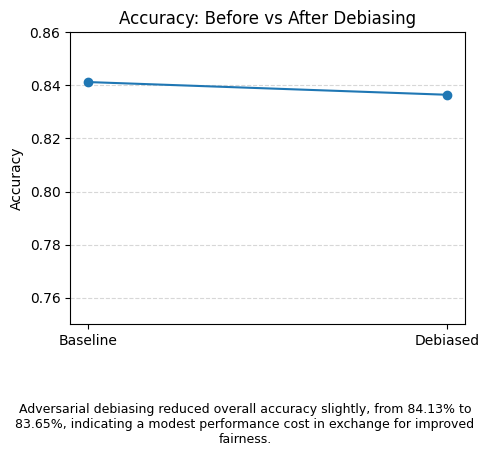

In [10]:
baseline_accuracy = accuracy_baseline.item()
debiased_accuracy = accuracyToBeFixed.item()
stages = ['Baseline', 'Debiased']

accuracy_values = [baseline_accuracy, debiased_accuracy]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(stages, accuracy_values, marker='o')
ax.set_ylim(0.75, 0.86)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Before vs After Debiasing')
ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.text(
    0.5, -0.02,
    f"Adversarial debiasing reduced overall accuracy slightly, from {baseline_accuracy:.2%} to {debiased_accuracy:.2%}, indicating a modest performance cost in exchange for improved fairness.",
    ha='center',
    va='top',
    fontsize=9,
    wrap=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(os.path.join(report_dir, 'accuracy_before_after.png'), dpi=300, bbox_inches='tight')

plt.show()